# Debugging Constraint Violations

1/29

The purpose is to compute the score functions from the kinetic energy and obstacle avoidance terms, to better understand why the obstacle avoidance constraint non-satisfaction might be happening. At the very least, I will visualize the optimization process for a simple problem where I expect this conflict-of-interest to occur. Then I'll investigate how the penetration depth is impacted by $\sigma$ and the kinetic energy weight. Further considerations are contingent on the results of these tests.

In [1]:
%load_ext autoreload
%autoreload 2

import sys

from pathlib import Path

path = Path("..").resolve().as_posix()
if str(path) not in sys.path:
    sys.path.insert(0, str(path))

<string>:14: RuntimeWarning: invalid value encountered in divide
<string>:32: RuntimeWarning: invalid value encountered in divide


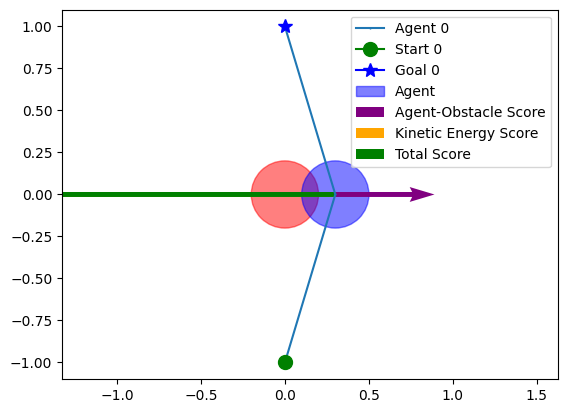

In [85]:
from matplotlib.axes import Axes
from ael.score_function import (
    compute_agent_obstacle_score_from_problem,
    compute_kinetic_energy_score,
)
import matplotlib.pyplot as plt
from ael.problem import Problem
from ael.visualize import visualize
import numpy as np


def show_result(
    problem: Problem, trajectory, sigma, score_obs, score_kin, score_total, agent_pos
):
    # Plot the score.
    ax: Axes = plt.gca()
    visualize(problem, ax, trajectory)
    ax.add_patch(
        plt.Circle(
            (agent_pos[0, 0], agent_pos[0, 1]),
            sigma,
            color="blue",
            alpha=0.5,
            label="Agent",
        )
    )
    ax.quiver(
        agent_pos[:, 0],
        agent_pos[:, 1],
        score_obs[:, 0],
        score_obs[:, 1],
        scale=5.0,
        width=0.01,
        color="purple",
        label="Agent-Obstacle Score",
    )
    ax.quiver(
        agent_pos[:, 0],
        agent_pos[:, 1],
        score_kin[:, 0],
        score_kin[:, 1],
        scale=5.0,
        width=0.01,
        color="orange",
        label="Kinetic Energy Score",
    )
    ax.quiver(
        agent_pos[:, 0],
        agent_pos[:, 1],
        score_total[:, 0],
        score_total[:, 1],
        scale=5.0,
        width=0.01,
        color="green",
        label="Total Score",
    )
    ax.axis("equal")
    ax.legend()
    plt.show()


def run(variable_x: float, sigma: float, kinetic_energy_weight: float):
    problem = Problem[np.ndarray](
        num_timesteps=3,
        agent_start_positions=np.array([[0.0, -1.0]]),
        agent_end_positions=np.array([[0.0, 1.0]]),
        agent_reference_trajectory=None,
        agent_radii=np.array([0.05]),
        agent_max_speeds=np.array([0.05]),
        obstacle_positions=np.array([[0.0, 0.0]]),
        obstacle_radii=np.array([0.2]),
    )
    trajectory = np.array([[[0.0, -1.0]], [[variable_x, 0.0]], [[0.0, 1.0]]])

    score_T_A_O_D, score_T_A1_A2_D = compute_agent_obstacle_score_from_problem(
        problem, trajectory, sigma=sigma, n_integral=20
    )
    score_kinetic = (
        compute_kinetic_energy_score(trajectory, sigma=sigma) * kinetic_energy_weight
    )

    # Isolate the t=1 scores for plotting.

    score_obs = score_T_A_O_D[1, :, 0, :]
    score_kin = score_kinetic[1, :, :]
    score_total = score_obs + score_kin
    agent_pos = trajectory[1, :, :]

    show_result(
        problem, trajectory, sigma, score_obs, score_kin, score_total, agent_pos
    )


run(variable_x=0.3, sigma=0.2, kinetic_energy_weight=50)


## Quantitative Results

For some quantitative results, I measure the agent-obstacle constraint violation value under variations in the $\sigma$ and kinetic energy weight terms. The dependent variable will be estimated from each independent variable after $100$ gradient steps using the Adam optimizer with $\eta = 0.5$, $\beta_1 = 0.9$, and $\beta_2 = 0.999$. The initial reference trajectory will be $(0, -1), (0.5, 0), (0, 1)$.

For variations in the independent variable, I will use $\sigma = 0.1, 0.01, 0.001, 0.0001$, and kinetic energy weights of $\text{KE} = 1, 2, 5, 10, 50$. I will then create two plots; one with the constraint violation on the $y$ axis and $\text{KE}$ on the $x$ axis, and another with the same $y$ axis and $\sigma$ on the $x$ axis.

In [109]:
from ael.solve import solve, ScheduleEntry

problem = Problem[np.ndarray](
    num_timesteps=3,
    agent_start_positions=np.array([[0.0, -1.0]]),
    agent_end_positions=np.array([[0.0, 1.0]]),
    agent_reference_trajectory=None,
    agent_radii=np.array([0.05]),
    agent_max_speeds=np.array([0.05]),
    obstacle_positions=np.array([[0.0, 0.0]]),
    obstacle_radii=np.array([0.2]),
)
initial_trajectory = np.array([[[0.0, -1.0]], [[0.5, 0.0]], [[0.0, 1.0]]])

sigma_values = [0.1, 0.01, 0.001, 0.0001]
kinetic_energy_weights = [1, 2, 5, 10, 50]

constraint_violations = np.zeros(
    (len(sigma_values), len(kinetic_energy_weights), 2), dtype=float
)

for i_sigma, sigma in enumerate(sigma_values):
    for i_ke, kinetic_energy_weight in enumerate(kinetic_energy_weights):
        result = solve(
            problem,
            schedule=[
                ScheduleEntry(
                    sigma=sigma,
                    num_steps=1000,
                    kinetic_weight=kinetic_energy_weight,
                    num_integral=1000,
                )
            ],
            initial_trajectory=initial_trajectory,
        )
        constraint_violations[i_sigma, i_ke, 0] = (
            result.agent_agent_constraint_residuals.max()
        )
        constraint_violations[i_sigma, i_ke, 1] = (
            result.agent_obstacle_constraint_residuals.max()
        )
        print(
            sigma,
            kinetic_energy_weight,
            result.trajectories[-1][1, 0, :],
            constraint_violations[i_sigma, i_ke],
        )


0.1 1 [-0.42073217  0.        ] [0. 0.]
0.1 2 [-0.2575  0.    ] [0. 0.]
0.1 5 [0.103 0.   ] [0.    0.147]
0.1 10 [0.0515 0.    ] [0.     0.1985]
0.1 50 [-0.0103  0.    ] [0.     0.2397]
0.01 1 [-0.33610315  0.        ] [0. 0.]
0.01 2 [-0.250075  0.      ] [0. 0.]
0.01 5 [-0.10003  0.     ] [0.      0.14997]
0.01 10 [0.050015 0.      ] [0.       0.199985]
0.01 50 [0.010003 0.      ] [0.       0.239997]
0.001 1 [-5.46603232e-23  0.00000000e+00] [0.   0.25]
0.001 2 [-7.76604082e-24  0.00000000e+00] [0.   0.25]
0.001 5 [5.48675238e-24 0.00000000e+00] [0.   0.25]
0.001 10 [-3.54707892e-24  0.00000000e+00] [0.   0.25]
0.001 50 [7.79960977e-24 0.00000000e+00] [0.   0.25]
0.0001 1 [-2.40658319e-25  0.00000000e+00] [0.   0.25]
0.0001 2 [-2.41154265e-25  0.00000000e+00] [0.   0.25]
0.0001 5 [-2.41451832e-25  0.00000000e+00] [0.   0.25]
0.0001 10 [-2.41551021e-25  0.00000000e+00] [0.   0.25]
0.0001 50 [-2.41630372e-25  0.00000000e+00] [0.   0.25]


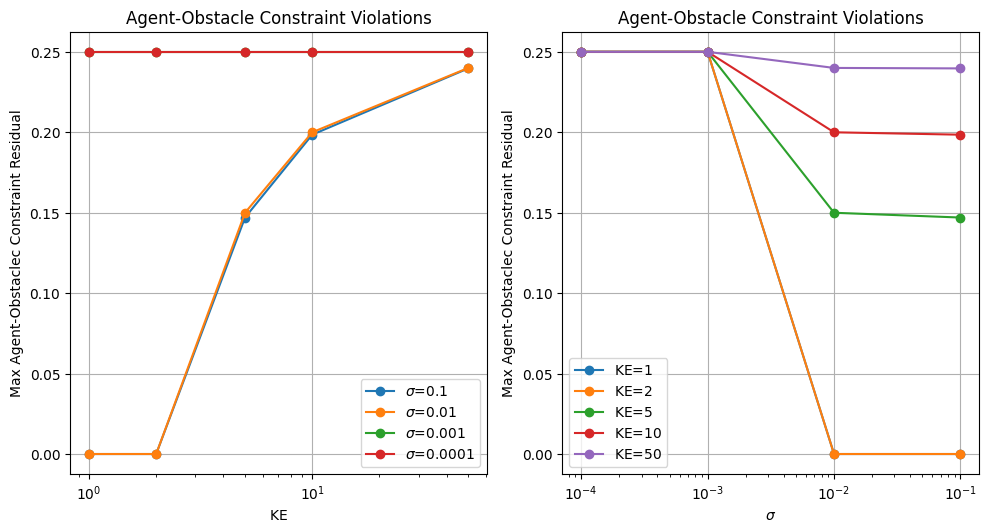

In [110]:
"""
Visualize the constraint violation results.
First row: Agent-agent constraint residuals.
Second row: Agent-obstacle constraint residuals.
First column: Varying kinetic energy weight.
Second column: Varying sigma.
"""

plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
for i_sigma in range(len(sigma_values)):
    plt.plot(
        kinetic_energy_weights,
        constraint_violations[i_sigma, :, 1],
        label=f"$\\sigma$={sigma_values[i_sigma]}",
        marker="o",
    )
plt.xscale("log")
plt.xlabel("$\\text{KE}$")
plt.ylabel("Max Agent-Obstaclec Constraint Residual")
plt.title("Agent-Obstacle Constraint Violations")
plt.legend()
plt.grid()

plt.subplot(2, 2, 2)
for i_ke in range(len(kinetic_energy_weights)):
    plt.plot(
        sigma_values,
        constraint_violations[:, i_ke, 1],
        label=f"$\\text{{KE}}$={kinetic_energy_weights[i_ke]}",
        marker="o",
    )
plt.xscale("log")
plt.xlabel("$\\sigma$")
plt.ylabel("Max Agent-Obstaclec Constraint Residual")
plt.title("Agent-Obstacle Constraint Violations")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()